<h3>Introduction and Objectives</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">
    
In this demo I wanted to showcase the extended potential of the PINN model that I developed for calendar ageing dataset. Kindly check out the project link where I had put the step-by-step explanations from background, dataset, PINN architechture, loss formuation, model evaluation, validation of electrochemical ageing assumption.

**PROJECT LINK**

New **Extended Capabilities of PINN**:(bounds of the PINN potential is decided by you)
- **Learning ability with very small dataset**(barely 10 points :) )
- **Forecasting capabilities**
- **Prediction power for new temperature(operating conditions) which is unseen in the train data**

**What kind of business values PINNs can actually bring?** . This demo will answer this question.

## Data Source and Experimental Testing Information

The experimental data used in this **Inverse Physics-Informed Neural Network (iPINN)** demonstration corresponds to calendar-ageing measurements of a commercial **Lithium Iron Phosphate (LFP)** cell. The objective of the original study was to investigate the impact of **storage temperature** on battery degradation under high State-of-Charge (SoC=100%) conditions.

The calendar-ageing data used in this study originates from the work of **Naumann et al.**, who investigated the degradation behaviour of commercial Lithium Iron Phosphate (LiFePO₄) cells under various storage conditions.

### Cell Specifications

- **Chemistry:** Lithium Iron Phosphate (LiFePO₄) cathode / Graphite anode
- **Manufacturer:** Sony / Murata **Sony US26650FTC1**

#### Cell Characteristics

- **Format:** 26650 Cylindrical Cell
- **Chemistry:** Lithium Iron Phosphate (LiFePO₄)
- **Nominal Capacity:** 3000 mAh
- **Nominal Voltage:** 3.2 V
- **Operating Voltage Range:** 2.0 V to 3.6 V

---

### Static Calendar-Ageing Study

The primary objective of the static ageing study was to quantify the impact of storage temperature and State of Charge (SoC) on long-term battery degradation.

**Test Conditions**

- **Test Duration:** 29 months
- **Number of Test Points:** 17
- **Operating Conditions:** Constant storage conditions
- **Variables Investigated:**
  - Temperature
  - State of Charge (SoC)
- **Sample Size:** 3 cells per test point

**Measured Quantities**

- Capacity degradation
- Internal resistance evolution

---

### Dynamic Calendar-Ageing Study (Model Validation)

A separate dynamic ageing campaign was conducted to validate the developed degradation models under more realistic operating conditions.

**Test Conditions**

- **Test Duration:** 9 months
- **Number of Test Points:** 3
- **Operating Conditions:** Time-varying storage conditions @ SoC = 100%
- **Variables Investigated:**
  - Temperature
  -

Unlike the static study, the dynamic ageing experiments exposed cells to changing operating conditions over time, providing a more challenging validation dataset for assessing model predictive capability.

---

### Relevance to This Work

The original study provided a comprehensive dataset for understanding calendar ageing in LiFePO₄ batteries. In this iPINN demonstration, a subset of the reported capacity-loss measurements is used to identify temperature-dependent degradation parameters directly from experimental observations while enforcing physically motivated ageing laws.

---

### Source

**Naumann, M. et al.**

*Analysis and Modeling of Calendar Aging of a Commercial LiFePO₄/Graphite Cell*

Journal of The Electrochemical Society.

📄 Paper:  
https://iopscience.iop.org/article/10.1149/1945-7111/ab7900/pdf

In [1]:
# ============================================================
# 1. Library Import
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# 2. Experimental Dataset
# ============================================================

# Full storage time (days)
time_days_full = [0,100,200,300,400,500,600,700,800,900]

# Capacity loss
loss_25C = [0.000,0.038,0.054,0.067,0.078,
            0.089,0.096,0.103,0.107,0.110]

loss_40C = [0.000,0.050,0.066,0.080,0.091,
            0.101,0.110,0.125,0.133,0.138]

loss_60C = [0.000,0.093,0.120,0.145,0.167,
            0.183,0.198,0.208,0.217,0.226]


def to_q_tensor(loss):
    return 1.0 - torch.tensor(loss,
                              dtype=torch.float32).unsqueeze(1)

q_25C = to_q_tensor(loss_25C)
q_40C = to_q_tensor(loss_40C)
q_60C = to_q_tensor(loss_60C)

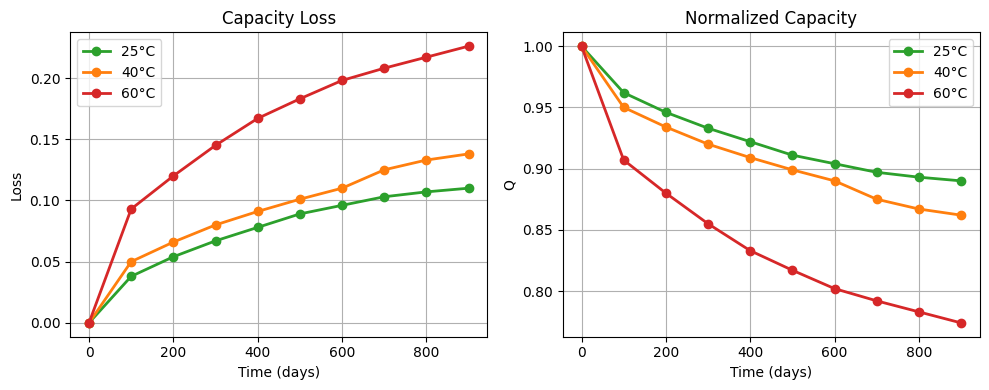

In [3]:
# ============================================================
# 3. Plot Raw Dataset
# ============================================================

loss_data = [loss_25C, loss_40C, loss_60C]
q_data = [q_25C, q_40C, q_60C]

colors = ["tab:green", "tab:orange", "tab:red"]
labels = ["25°C", "40°C", "60°C"]

fig, ax = plt.subplots(1,2,figsize=(10,4))

for loss, q, c, lbl in zip(loss_data,
                           q_data,
                           colors,
                           labels):

    ax[0].plot(time_days_full,
               loss,
               "o-",
               color=c,
               lw=2,
               label=lbl)

    ax[1].plot(time_days_full,
               q.numpy().flatten(),
               "o-",
               color=c,
               lw=2,
               label=lbl)

ax[0].set_title("Capacity Loss")
ax[0].set_xlabel("Time (days)")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

ax[1].set_title("Normalized Capacity")
ax[1].set_xlabel("Time (days)")
ax[1].set_ylabel("Q")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

<h3>Data Visualization</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">
    
**Figure:** Experimental calendar-ageing dataset used in this study. The left subplot shows the measured capacity loss, while the right subplot shows the corresponding normalized remaining capacity (\(Q = 1 - Loss\)) used as the target variable for the iPINN.

The influence of temperature is clearly visible in both representations. Cells stored at **60°C** exhibit the most severe degradation, followed by **40°C**, while the **25°C** cells experience the smallest capacity fade over the 900-day storage period. The non-linear shape of the degradation curves suggests that ageing is most rapid during the early stages of storage and gradually slows down with time, which is consistent with diffusion-limited SEI growth mechanisms commonly reported in lithium-ion batteries.

The normalized-capacity representation is particularly convenient for PINN training because it directly reflects battery State-of-Health (SoH), with all cells starting from a common initial condition of \(Q(0)=1\).

### Out of 3 cells data, we will use only two (25degC and 45degC) and partial data upto 500 cycles

In [44]:
# ============================================================
# 4. Training Dataset
# ============================================================

time_days_train = [0,100,200,300,400, 500]

t_data = torch.tensor(
    time_days_train,
    dtype=torch.float32
).unsqueeze(1)

q_25_train = q_25C[:6]
q_60_train = q_60C[:6]

datasets = {
    "25°C": q_25_train,
    "60°C": q_60_train
}

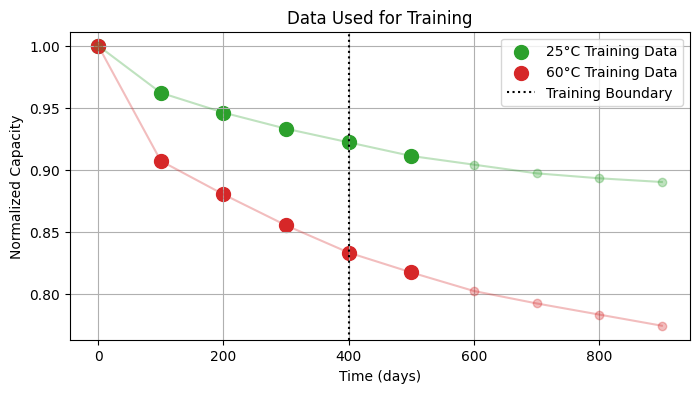

In [45]:
# ============================================================
# 5. Training Data Visualization
# ============================================================

plt.figure(figsize=(8,4))

plt.plot(time_days_full,
         q_25C.numpy().flatten(),
         "o-",
         color="tab:green",
         alpha=0.3)

plt.plot(time_days_full,
         q_60C.numpy().flatten(),
         "o-",
         color="tab:red",
         alpha=0.3)

plt.scatter(
    time_days_train,
    q_25_train.numpy().flatten(),
    s=100,
    color="tab:green",
    label="25°C Training Data"
)

plt.scatter(
    time_days_train,
    q_60_train.numpy().flatten(),
    s=100,
    color="tab:red",
    label="60°C Training Data"
)

plt.axvline(
    400,
    linestyle=":",
    color="black",
    label="Training Boundary"
)

plt.xlabel("Time (days)")
plt.ylabel("Normalized Capacity")
plt.title("Data Used for Training")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
# ============================================================
# 6. PINN Architecture
# ============================================================

class BatteryPINN(nn.Module):

    def __init__(self):

        super().__init__()

        self.t_max = 900.0

        self.net = nn.Sequential(
            nn.Linear(1,32), nn.Tanh(),
            nn.Linear(32,32), nn.Tanh(),
            nn.Linear(32,1)
        )

        self.k_raw = nn.Parameter(torch.tensor(-5.3))
        self.b_raw = nn.Parameter(torch.tensor(-9.0))

    @property
    def k(self):
        return F.softplus(self.k_raw)

    @property
    def b(self):
        return F.softplus(self.b_raw)

    def forward(self,t):
        return self.net(t/self.t_max)

In [47]:
# ============================================================
# 7. PINN Loss Function
# ============================================================

def pinn_loss(model,
              t_data,
              q_true,
              t_phys,
              lambda_data=1,
              lambda_phys=1,
              lambda_ic=1):

    mse = nn.MSELoss()

    loss_data = mse(
        model(t_data),
        q_true
    )

    q_phys = model(t_phys)

    dQ_dt = torch.autograd.grad(
        q_phys,
        t_phys,
        grad_outputs=torch.ones_like(q_phys),
        create_graph=True
    )[0]

    sqrt_t = torch.sqrt(t_phys)

    residual = (
        sqrt_t*dQ_dt
        + model.k
        + model.b*sqrt_t
    )

    loss_phys = torch.mean(residual**2)

    t0 = torch.zeros((1,1))

    loss_ic = mse(
        model(t0),
        torch.ones((1,1))
    )

    loss_total = (
        lambda_data*loss_data
        + lambda_phys*loss_phys
        + lambda_ic*loss_ic
    )

    return (
        loss_total,
        loss_data,
        loss_phys,
        loss_ic
    )

In [48]:
datasets = {
    "25°C": q_25_train,
    "60°C": q_60_train
}

### Let us train the model with just the 2 cell data now!!!

In [32]:
# ============================================================
# 3. Model Setup and Training
# ============================================================
results = {}

for temp, q_train in datasets.items():

    print(f"\nTraining PINN for {temp}")

    model = BatteryPINN()

    # Physics collocation points
    t_phys = torch.linspace(
        0.1, 900.0, 50
    ).unsqueeze(1).requires_grad_(True)

    # Independent learning rates
    optimizer = torch.optim.Adam([
        {"params": model.net.parameters(), "lr": 1e-3},
        {"params": [model.k_raw, model.b_raw], "lr": 3e-3}
    ])

    # History
    loss_history = []
    data_loss_history = []
    physics_loss_history = []
    ic_loss_history = []

    epochs = 20001

    for epoch in range(epochs + 1):

        model.train()
        optimizer.zero_grad()

        total_loss, data_loss, physics_loss, ic_loss = pinn_loss(
            model,
            t_data,
            q_train,
            t_phys,
            lambda_data=1.0,
            lambda_phys=1.0,
            lambda_ic=1.0
        )

        total_loss.backward()
        optimizer.step()

        loss_history.append(total_loss.item())
        data_loss_history.append(data_loss.item())
        physics_loss_history.append(physics_loss.item())
        ic_loss_history.append(ic_loss.item())

        if epoch % 5000 == 0:

            print(
                f"Epoch {epoch:05d} | "
                f"Total: {total_loss.item():.6e} | "
                f"Data: {data_loss.item():.6e} | "
                f"Physics: {physics_loss.item():.6e} | "
                f"IC: {ic_loss.item():.6e}"
            )

            print(
                f"k = {model.k.item():.7f} | "
                f"b = {model.b.item():.7f}"
            )

    # Store discovered parameters
    results[temp] = {
        "model": model,
        "k": model.k.item(),
        "b": model.b.item(),
        "a": 2 * model.k.item(),
        "loss_history": loss_history,
        "data_loss_history": data_loss_history,
        "physics_loss_history": physics_loss_history,
        "ic_loss_history": ic_loss_history
    }


Training PINN for 25°C
Epoch 00000 | Total: 3.983289e+00 | Data: 1.870748e+00 | Physics: 1.342178e-04 | IC: 2.112407e+00
k = 0.0049643 | b = 0.0001230
Epoch 05000 | Total: 8.207437e-06 | Data: 7.603645e-06 | Physics: 4.311476e-07 | IC: 1.726436e-07
k = 0.0006414 | b = 0.0000839
Epoch 10000 | Total: 9.224035e-07 | Data: 4.779309e-07 | Physics: 4.433102e-07 | IC: 1.162391e-09
k = 0.0004345 | b = 0.0001284
Epoch 15000 | Total: 2.863892e-07 | Data: 1.351294e-07 | Physics: 1.511288e-07 | IC: 1.309672e-10
k = 0.0011307 | b = 0.0000739
Epoch 20000 | Total: 1.243013e-07 | Data: 5.154211e-08 | Physics: 7.251154e-08 | IC: 2.476099e-10
k = 0.0015179 | b = 0.0000430

Training PINN for 60°C
Epoch 00000 | Total: 1.170350e+00 | Data: 4.974559e-01 | Physics: 6.684793e-05 | IC: 6.728271e-01
k = 0.0049643 | b = 0.0001230
Epoch 05000 | Total: 5.148789e-05 | Data: 4.895004e-05 | Physics: 1.818252e-06 | IC: 7.196015e-07
k = 0.0031374 | b = 0.0000058
Epoch 10000 | Total: 1.204089e-05 | Data: 9.721078e-06 |

In [33]:
results[temp] = {
    "model": model,
    "k": model.k.item(),
    "b": model.b.item()
}

In [55]:
# ============================================================
# 9. Extract Discovered Parameters
# ============================================================

print("\n" + "="*60)
print("FINAL DISCOVERED DEGRADATION PARAMETERS")
print("="*60)

print(f"{'Temp':<10}{'k (SEI)':<14}{'b (Linear)':<14}")
print("-"*60)

for temp, res in results.items():
    print(
        f"{temp:<10}"
        f"{res['k']:<14.7f}"
        f"{res['b']:<14.7f}"
    )

print("="*60)

k_25 = results["25°C"]["k"]
k_60 = results["60°C"]["k"]

b_25 = results["25°C"]["b"]
b_60 = results["60°C"]["b"]


FINAL DISCOVERED DEGRADATION PARAMETERS
Temp      k (SEI)       b (Linear)    
------------------------------------------------------------
25°C      0.0015180     0.0000430     
60°C      0.0035869     0.0000002     


<h3>What can we understand from the Ageing Parameters?</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

The iPINN successfully identified physically meaningful degradation parameters for both storage temperatures.

A clear trend can be observed in the discovered **SEI-growth parameter \(k\)**:

- **25°C:** \(k = 0.0015180\)
- **60°C:** \(k = 0.0035869\)

The value of \(k\) increases by more than a factor of two between 25°C and 60°C, indicating significantly faster degradation kinetics at elevated temperatures. This behavior is consistent with the widely accepted understanding that higher temperatures accelerate electrochemical side reactions and SEI-layer growth, leading to increased capacity fade.

The **linear-ageing parameter \(b\)** remains extremely small for both temperatures and is several orders of magnitude smaller than the SEI contribution:

- **25°C:** \(b = 4.3 \times 10^{-5}\)
- **60°C:** \(b = 2.0 \times 10^{-7}\)

Even before performing Arrhenius analysis, the monotonic increase of \(k\) with temperature provides an encouraging indication that the iPINN has recovered degradation parameters that are physically meaningful rather than merely fitting the available data. The next step is to examine whether the discovered parameters follow the Arrhenius relationship, which serves as an additional validation of their physical consistency.

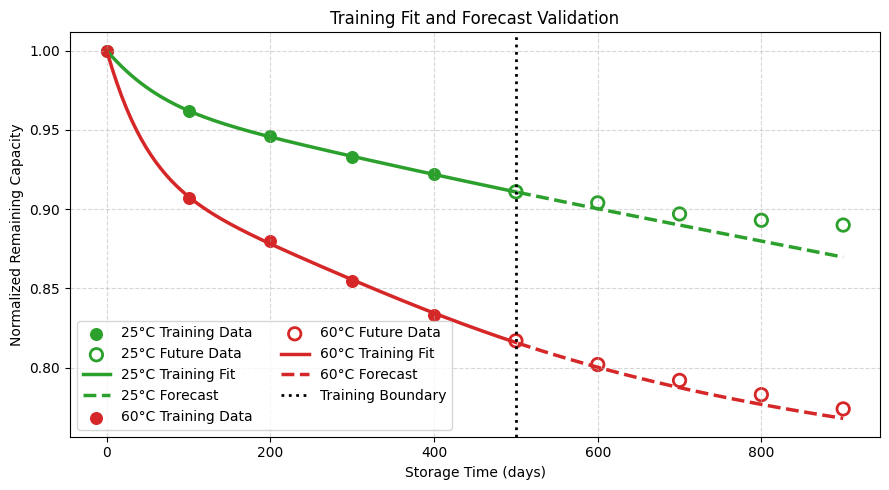

In [67]:
# ============================================================
# 14. Forecast Validation
# ============================================================
t_plot = torch.linspace(0, 900, 300).unsqueeze(1)

time_days_train = [0,100,200,300,400]

full_data = {
    "25°C": q_25C,
    "60°C": q_60C
}

colors = ["tab:green", "tab:red"]

plt.figure(figsize=(9,5))

for (temp, q_full), color in zip(
    full_data.items(),
    colors
):

    model = results[temp]["model"]

    with torch.no_grad():
        q_pred = model(t_plot).cpu().numpy().flatten()

    t_pred = t_plot.cpu().numpy().flatten()

    train_mask = t_pred <= 500
    forecast_mask = t_pred >= 500

    q_full_np = q_full.numpy().flatten()

    # Training points
    plt.scatter(
        time_days_full[:5],
        q_full_np[:5],
        color=color,
        s=70,
        label=f"{temp} Training Data"
    )

    # Future points
    plt.scatter(
        time_days_full[5:],
        q_full_np[5:],
        facecolors="none",
        edgecolors=color,
        s=80,
        linewidths=2,
        label=f"{temp} Future Data"
    )

    # Fit region
    plt.plot(
        t_pred[train_mask],
        q_pred[train_mask],
        color=color,
        lw=2.5,
        label=f"{temp} Training Fit"
    )

    # Forecast region
    plt.plot(
        t_pred[forecast_mask],
        q_pred[forecast_mask],
        "--",
        color=color,
        lw=2.5,
        label=f"{temp} Forecast"
    )

plt.axvline(
    500,
    color="black",
    linestyle=":",
    linewidth=2,
    label="Training Boundary"
)

plt.xlabel("Storage Time (days)")
plt.ylabel("Normalized Remaining Capacity")
plt.title("Training Fit and Forecast Validation")
plt.grid(True, ls="--", alpha=0.5)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

In [68]:
for temp, q_full in full_data.items():

    model = results[temp]["model"]

    with torch.no_grad():
        q_pred = model(
            torch.tensor(time_days_full,
                         dtype=torch.float32)
            .unsqueeze(1)
        ).cpu().numpy().flatten()

    q_true = q_full.numpy().flatten()

    for name, idx in {
        "Training": slice(0, 6),
        "Forecast": slice(6, None)
    }.items():

        y_true = q_true[idx]
        y_pred = q_pred[idx]

        r2 = 1 - np.sum((y_true-y_pred)**2) / \
                    np.sum((y_true-np.mean(y_true))**2)

        rmse = np.sqrt(
            np.mean((y_true-y_pred)**2)
        )

        print(
            f"{temp} | {name:8s} | "
            f" RMSE = {rmse:.5f}"
        )

25°C | Training |  RMSE = 0.00023
25°C | Forecast |  RMSE = 0.01268
60°C | Training |  RMSE = 0.00115
60°C | Forecast |  RMSE = 0.00492


<h3>How far is the Forecasting?</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

The forecasting results are quite encouraging, particularly considering that the model was trained using only the first **500 days** of degradation data.

| Temperature | Training RMSE | Forecast RMSE |
|------------|--------------:|--------------:|
| 25°C | 0.00023 | 0.01268 |
| 60°C | 0.00115 | 0.00492 |

As expected, the training errors are extremely small because the PINN has direct access to these measurements during optimization. The low training RMSE values confirm that the model successfully captures the degradation behaviour within the observed training window.

The more interesting result is the forecast performance beyond 500 days. Although the forecast RMSE increases compared to the training error, the prediction errors remain relatively small considering that the model is extrapolating several hundred days beyond the available training data.

An interesting observation is that the **60°C forecast performs better than the 25°C forecast**. This may indicate that degradation at elevated temperatures is governed more strongly by the dominant SEI-growth mechanism embedded in the physics model, making the long-term behaviour easier to extrapolate. In contrast, degradation at lower temperatures is slower and may be influenced more heavily by secondary mechanisms that are not fully captured by the simplified ageing equation.

Overall the forecasting capability of the PINN model is impressive according to me because of the value this model brings to the table.
- **The experimental time can be saved upto 50% (1 year can be saved)**

### 40°C Cell data is protected to test the models power. Next up we try to calculate the parameters based on the Arrhenius law and look at the R-squared and RMSE

In [69]:
# ============================================================
# 10. Arrhenius Interpolation
# ============================================================

T_train = np.array([25, 60]) + 273.15

x = 1 / T_train
y = np.log([k_25, k_60])

slope, intercept = np.polyfit(x, y, 1)

T_40 = 40 + 273.15

k_40 = np.exp(
    intercept + slope * (1 / T_40)
)

# Linear interpolation for b
b_40 = np.interp(
    40,
    [25, 60],
    [b_25, b_60]
)

print(f"k(40°C) = {k_40:.7f}")
print(f"b(40°C) = {b_40:.7f}")

k(40°C) = 0.0022467
b(40°C) = 0.0000246


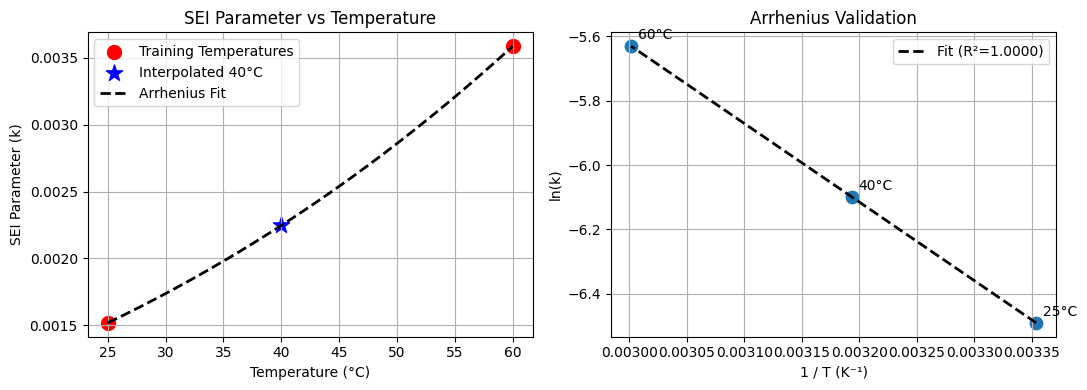

In [73]:
# ============================================================
# 11. Arrhenius Validation
# ============================================================

temps_C = np.array([25, 40, 60])
temps_K = temps_C + 273.15

k_all = np.array([k_25, k_40, k_60])

# R² should be computed only from the trained points
x_train = 1 / (np.array([25, 60]) + 273.15)
y_train = np.log([k_25, k_60])

slope_arr, intercept_arr = np.polyfit(
    x_train,
    y_train,
    1
)

y_fit_train = slope_arr * x_train + intercept_arr

r2_arr = 1 - np.sum(
    (y_train - y_fit_train)**2
) / np.sum(
    (y_train - np.mean(y_train))**2
)

T_curve = np.linspace(25, 60, 200)

k_curve = np.exp(
    intercept_arr +
    slope_arr * (1 / (T_curve + 273.15))
)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# -----------------------------------------
# k vs Temperature
# -----------------------------------------

ax[0].scatter(
    [25, 60],
    [k_25, k_60],
    color="red",
    s=100,
    label="Training Temperatures"
)

ax[0].scatter(
    [40],
    [k_40],
    color="blue",
    marker="*",
    s=150,
    label="Interpolated 40°C"
)

ax[0].plot(
    T_curve,
    k_curve,
    "k--",
    lw=2,
    label="Arrhenius Fit"
)

ax[0].set_xlabel("Temperature (°C)")
ax[0].set_ylabel("SEI Parameter (k)")
ax[0].set_title("SEI Parameter vs Temperature")
ax[0].grid(True)
ax[0].legend()

# -----------------------------------------
# Arrhenius Plot
# -----------------------------------------

x_all = 1 / temps_K
y_all = np.log(k_all)

ax[1].scatter(
    x_all,
    y_all,
    color="tab:blue",
    s=80
)

ax[1].plot(
    x_all,
    slope_arr*x_all + intercept_arr,
    "k--",
    lw=2,
    label=f"Fit (R²={r2_arr:.4f})"
)

for T, x0, y0 in zip(
    temps_C,
    x_all,
    y_all
):
    ax[1].annotate(
        f"{T}°C",
        (x0, y0),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax[1].set_xlabel("1 / T (K⁻¹)")
ax[1].set_ylabel("ln(k)")
ax[1].set_title("Arrhenius Validation")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

<h3>Interpretation of the Discovered SEI Parameter</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">


The iPINN identified the following SEI-growth parameters:

| Temperature | SEI Parameter (\(k\)) |
|------------|----------------------:|
| 25°C | 0.0015180 |
| 40°C (Interpolated) | 0.0022467 |
| 60°C | 0.0035869 |

A clear and physically meaningful trend is observed:

$$
k_{25^\circ C}
<
k_{40^\circ C}
<
k_{60^\circ C}
$$

The SEI parameter increases monotonically with temperature, indicating that the degradation kinetics accelerate as the storage temperature increases. Between **25°C** and **60°C**, the discovered SEI degradation rate increases by more than a factor of two, suggesting a strong temperature dependence of the underlying ageing mechanism.

This behavior is consistent with the widely accepted understanding that elevated temperatures accelerate electrochemical side reactions and SEI-layer growth, leading to faster loss of cyclable lithium and increased capacity degradation.

In [70]:
# ============================================================
# 12. Predict 40°C Degradation
# ============================================================

time_days_full = np.array(
    [0,100,200,300,400,500,600,700,800,900]
)

loss_40_pred = (
    2*k_40*np.sqrt(time_days_full)
    + b_40*time_days_full
)

q_40_pred = 1 - loss_40_pred

q_40_exp = q_40C.numpy().flatten()

In [72]:
# ============================================================
# 13. Validation Metrics
# ============================================================

r2_40 = (
    1
    - np.sum((q_40_exp - q_40_pred)**2)
      / np.sum((q_40_exp - np.mean(q_40_exp))**2)
)

rmse_40 = np.sqrt(
    np.mean((q_40_exp - q_40_pred)**2)
)

from IPython.display import display, HTML

display(HTML(f"""
<div style="font-size:20px;font-weight:bold;color:darkblue;">
40°C Prediction R² = {r2_40:.5f}<br>
40°C Prediction RMSE = {rmse_40:.6f}
</div>
"""))

<h3>Uncovering the Mysteries @ **@40°C**</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

The unseen **40°C validation case** achieved an **R² of 0.929** and an **RMSE of 0.0107**, which is encouraging considering that the model was never trained on data from this temperature. The prediction was generated solely from the degradation parameters identified at **25°C** and **60°C**, together with Arrhenius-based interpolation.

- **If you remember the number of datapoints we used for training, the correlation for the test case temperature is amazing!!**

Although the accuracy is lower than that observed at the training temperatures, the model successfully captures the overall degradation trend at 40°C. 

I am sure that if we had used data upto 700-800 days for training, then we could see a better accuracy for the unseen cases

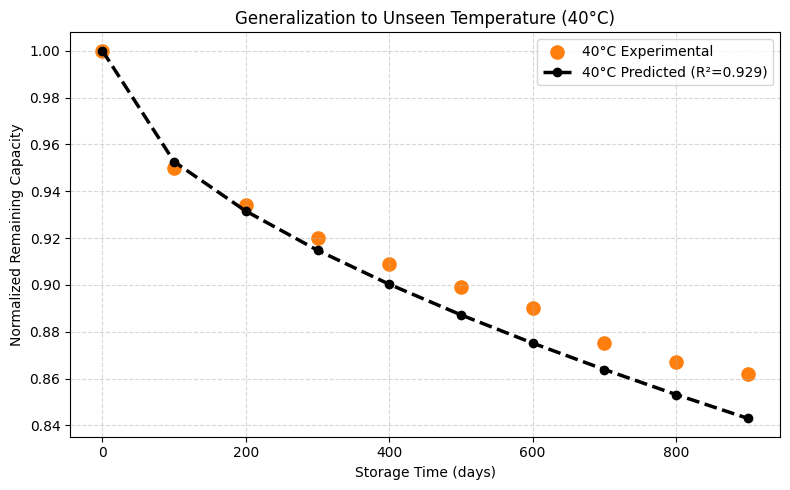

In [41]:
# ============================================================
# 15. Unseen Temperature Validation
# ============================================================

plt.figure(figsize=(8,5))

plt.scatter(
    time_days_full,
    q_40_exp,
    color="tab:orange",
    s=90,
    label="40°C Experimental"
)

plt.plot(
    time_days_full,
    q_40_pred,
    "k--o",
    lw=2.5,
    label=f"40°C Predicted (R²={r2_40:.3f})"
)

plt.xlabel("Storage Time (days)")
plt.ylabel("Normalized Remaining Capacity")
plt.title("Generalization to Unseen Temperature (40°C)")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

<h3>Conslusion</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

Things that I wanted to demonstrate 
- **Train PINN with small data and test the capabilities of the model : The model did pretty good job.**
- **Forecasting ability (Extrapolation potential) : Since the model learns the underlying mechanism the extrapolation looks cool.**
- **Predictin the degradation for a new storage condition: the prediction emphasizes the tru potential of PINNs**

This kind of model can **bring business values**:
- **Reduce the experimental time**
- **Reduce the number of test cases**
  
**Thus reducing the cost and shortening the time-line of product development.**